### V16 - Oszillometrische Blutdruckmessung (iOBP)

In diesem Versuch haben wir mit zwei Blutdruckmessgeräten (Beurer und Nais) Refernzmessungen durchgeführt.
Außerdem mit einem Prototypischen-Gerät, für dessen Messungen ein Algorithmus entwickelt wurde, um den Refenzmessungen möglichst Nahe zu kommen.

Dieser Algorithmus findet sich in der Datei `BlutdruckMesser.py`. Der Algorithmus hat insgesamt 9 einstellbare Parameter. Da eine manuelle Einstellung dieser zu aufwendig wäre, haben wir eine Biobliothek namens Optuna (https://optuna.org) dafür verwendet. In der Datei `optimzer.py` wurden dann die Parameter optimiert und die Ausgabe haben wir in den `results parameter.txt` gespeichert.

In diesem Jupiter Notebook werden wir nun alle Messungen analysieren, plotten und die Abweichung zur Referenz berechnen.

In [1]:
import numpy as np
import plotly.graph_objects as go
from BlutdruckMesser import alogrithmus
from Messungen.Infos import MEASUREMENT_INFORMATION, COMBINED_BEST, BEURER_BEST, NAIS_BEST

catagories = [
    (COMBINED_BEST, "Beurer und Nais", "combined"),
    (BEURER_BEST, "Beurer", "beurer"),
    (NAIS_BEST, "Nais", "nais")
]

def plot_bland_altman(method1, method2, title, ax):
        method1 = np.asarray(method1)
        method2 = np.asarray(method2)

        # Mittelwert beider Methoden (X-Achse)
        mean = np.mean([method1, method2], axis=0)
        # Differenz (Algorithmus - Referenz) (Y-Achse)
        diff = method1 - method2

        bias = np.mean(diff)                   # Systematischer Fehler
        sd = np.std(diff, ddof=1)              # Standardabweichung der Differenzen

        # Limits of Agreement (LoA)
        upper_loa = bias + 1.96 * sd
        lower_loa = bias - 1.96 * sd

        # Streudiagramm
        ax.scatter(mean, diff, alpha=0.7, color='blue', edgecolor='k')

        # Horizontale Linien für Bias und LoA
        ax.axhline(bias, color='red', linestyle='-', linewidth=2, label=f'Bias: {bias:.2f}')
        ax.axhline(upper_loa, color='green', linestyle='--', linewidth=2, label=f'+1.96 SD: {upper_loa:.2f}')
        ax.axhline(lower_loa, color='green', linestyle='--', linewidth=2, label=f'-1.96 SD: {lower_loa:.2f}')

        # Beschriftungen
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Mittelwert beider Methoden [mmHg]', fontsize=10)
        ax.set_ylabel('Differenz (Algorithmus - Referenz) [mmHg]', fontsize=10)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, linestyle=':', alpha=0.6)

def create_bland_altman_plotly(calc_vals, ref_vals, labels, title):
    if not calc_vals: return None

    calc_vals = np.array(calc_vals)
    ref_vals = np.array(ref_vals)

    # X-Achse: Mittelwert aus Algorithmus und Referenz
    means = (calc_vals + ref_vals) / 2
    # Y-Achse: Differenz (Algorithmus - Referenz)
    diffs = calc_vals - ref_vals

    bias = np.mean(diffs)
    sd = np.std(diffs, ddof=1) if len(diffs) > 1 else 0
    upper_loa = bias + 1.96 * sd
    lower_loa = bias - 1.96 * sd

    fig = go.Figure()

    # Interaktive Punkte hinzufügen
    fig.add_trace(go.Scatter(
        x=means, y=diffs, mode='markers', name='Messungen',
        text=labels, # Hier verstecken wir die Messnummer
        hovertemplate="<b>Messung: %{text}</b><br>Mittelwert: %{x:.1f} mmHg<br>Fehler (Algo-Ref): %{y:.1f} mmHg<extra></extra>",
        marker=dict(size=10, color='royalblue', opacity=0.7, line=dict(width=1, color='black'))
    ))

    # Bias- und LoA-Linien
    fig.add_hline(y=bias, line_dash="solid", line_color="red", annotation_text=f"Bias: {bias:.2f}")
    fig.add_hline(y=upper_loa, line_dash="dash", line_color="green", annotation_text=f"+1.96 SD: {upper_loa:.2f}")
    fig.add_hline(y=lower_loa, line_dash="dash", line_color="green", annotation_text=f"-1.96 SD: {lower_loa:.2f}")

    fig.update_layout(
        title=title,
        xaxis_title="Mittelwert beider Methoden [mmHg]",
        yaxis_title="Differenz (Algorithmus - Referenz) [mmHg]",
        hovermode="closest",
        template="plotly_white"
    )
    return fig

def run_analysis(categorie):
    print(f"\n\n\n=== Analsiere mit Paramtern optimiert für {categorie[1]} ===")
    # 2. Listen für die RAW-Werte (Berechnet vs. Referenz)
    data_beurer = {'sys_calc': [], 'sys_ref': [], 'dia_calc': [], 'dia_ref': [], 'labels': []}
    data_nais = {'sys_calc': [], 'sys_ref': [], 'dia_calc': [], 'dia_ref': [], 'labels': []}
    data_combined = {'sys_calc': [], 'sys_ref': [], 'dia_calc': [], 'dia_ref': [], 'labels': []}

    for messnummer, value in MEASUREMENT_INFORMATION.items():
        print(f"Analysieren der Messung: {messnummer}")

        b_sys, b_dia = value.get("Beurer", (None, None))
        n_sys, n_dia = value.get("NAIS", (None, None))

        # print(str(categorie[0]))

        calc_sys, calc_dia, signal = alogrithmus(messnummer=messnummer, **categorie[0])

        signal.plot_data(title=f"Optimized for {categorie[1]}: {messnummer}", filename=f"{categorie[2]}_{messnummer}", save_plot=False)

        # Auswertung Beurer
        # Daten für Beurer sammeln
        if b_sys is not None and b_dia is not None:
            data_beurer['sys_calc'].append(calc_sys)
            data_beurer['sys_ref'].append(float(b_sys))
            data_beurer['dia_calc'].append(calc_dia)
            data_beurer['dia_ref'].append(float(b_dia))
            data_beurer['labels'].append(messnummer)

        else:    # Auch in die kombinierte Liste werfen
            data_combined['sys_calc'].append(calc_sys)
            data_combined['sys_ref'].append(float(n_sys))
            data_combined['dia_calc'].append(calc_dia)
            data_combined['dia_ref'].append(float(n_dia))
            data_combined['labels'].append(f"{messnummer} (NAIS)")

        # Daten für NAIS sammeln
        if n_sys is not None and n_dia is not None:
            data_nais['sys_calc'].append(calc_sys)
            data_nais['sys_ref'].append(float(n_sys))
            data_nais['dia_calc'].append(calc_dia)
            data_nais['dia_ref'].append(float(n_dia))
            data_nais['labels'].append(messnummer)

        else:    # Auch in die kombinierte Liste werfen
            data_combined['sys_calc'].append(calc_sys)
            data_combined['sys_ref'].append(float(b_sys))
            data_combined['dia_calc'].append(calc_dia)
            data_combined['dia_ref'].append(float(b_dia))
            data_combined['labels'].append(f"{messnummer} (Beurer)")

        if n_sys is not None and n_dia is not None and b_sys is not None and b_dia is not None:
            data_combined['sys_calc'].append(calc_sys)
            data_combined['sys_ref'].append(np.mean([float(b_sys), float(n_sys)]))
            data_combined['dia_calc'].append(calc_dia)
            data_combined['dia_ref'].append(np.mean([float(b_dia), float(n_dia)]))
            data_combined['labels'].append(f"{messnummer} (Combined)")


    # 4. Plots generieren und anzeigen
    plots = [
        create_bland_altman_plotly(data_beurer['sys_calc'], data_beurer['sys_ref'], data_beurer['labels'], "Bland-Altman: Systole (Algorithmus vs. Beurer)"),
        create_bland_altman_plotly(data_beurer['dia_calc'], data_beurer['dia_ref'], data_beurer['labels'], "Bland-Altman: Diastole (Algorithmus vs. Beurer)"),
        create_bland_altman_plotly(data_nais['sys_calc'], data_nais['sys_ref'], data_nais['labels'], "Bland-Altman: Systole (Algorithmus vs. NAIS)"),
        create_bland_altman_plotly(data_nais['dia_calc'], data_nais['dia_ref'], data_nais['labels'], "Bland-Altman: Diastole (Algorithmus vs. NAIS)"),
        create_bland_altman_plotly(data_combined['sys_calc'], data_combined['sys_ref'], data_combined['labels'], "Bland-Altman: Systole (Algorithmus vs. Alle Referenzen)"),
        create_bland_altman_plotly(data_combined['dia_calc'], data_combined['dia_ref'], data_combined['labels'], "Bland-Altman: Diastole (Algorithmus vs. Alle Referenzen)"),
    ]

    # Zeigt alle generierten Plots im Browser an
    for p in plots:
        if p:
            p.show()

### Messungen optimiert auf Kombination zwischen Beurer und NAIS

In [ ]:
run_analysis(catagories[0])

### Messungen optimiert auf Beurer




=== Analsiere mit Paramtern optimiert für Beurer ===
Analysieren der Messung: P01_REST_01_100825


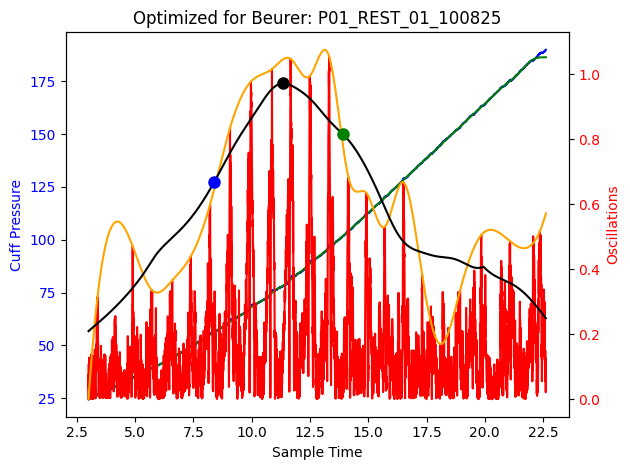

Analysieren der Messung: P01_REST_02_100825


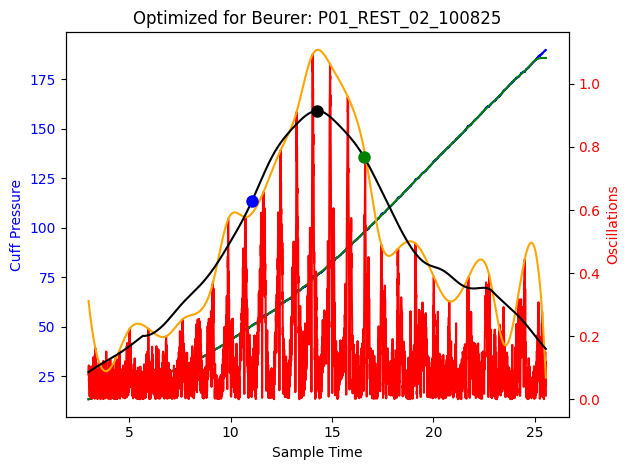

Analysieren der Messung: P01_ACTIV_01_160925


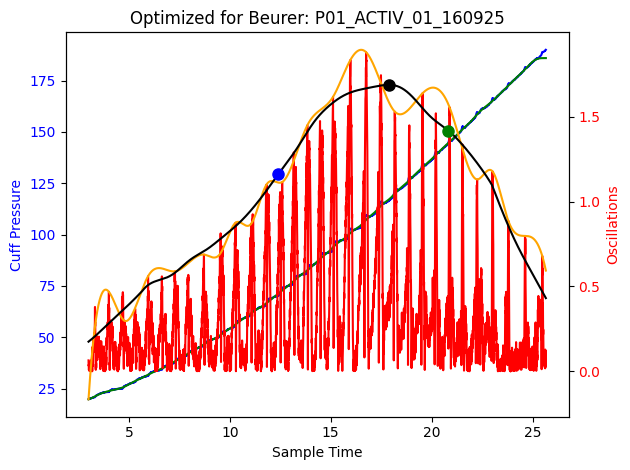

Analysieren der Messung: P02_REST_01_100825


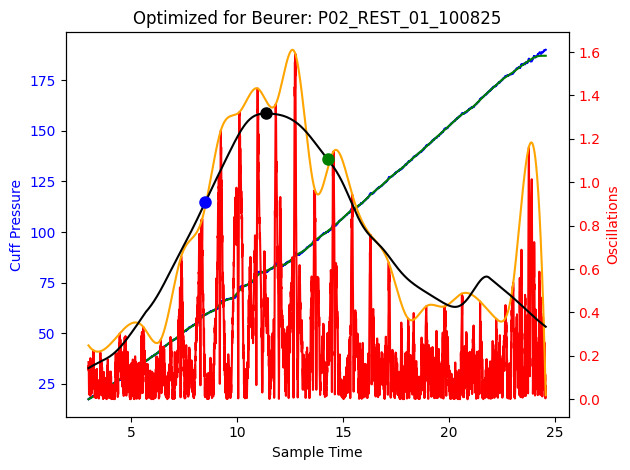

Analysieren der Messung: P02_REST_02_160925


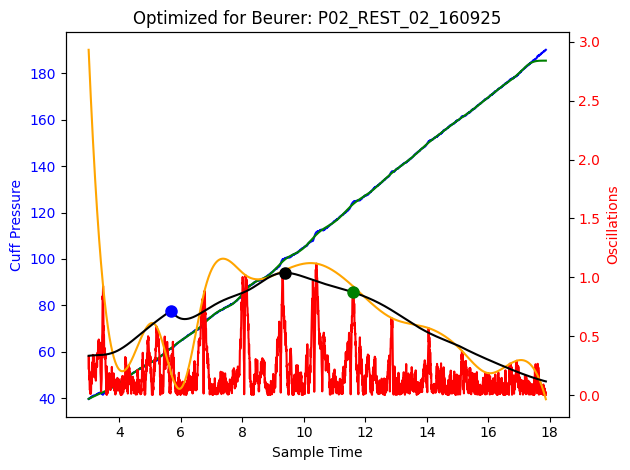

Analysieren der Messung: P02_ACTIV_01_160925


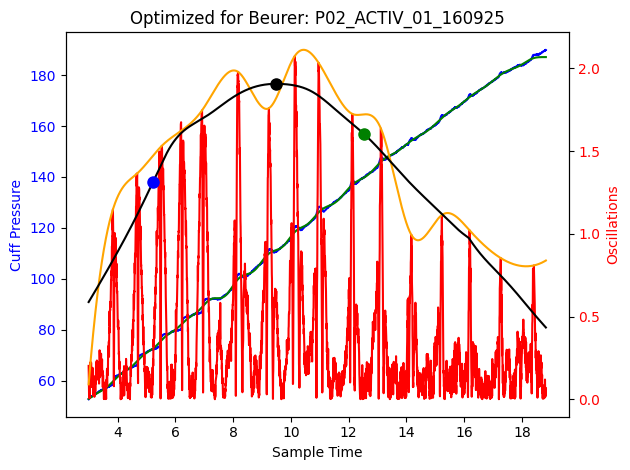

Analysieren der Messung: P03_REST_01_100825


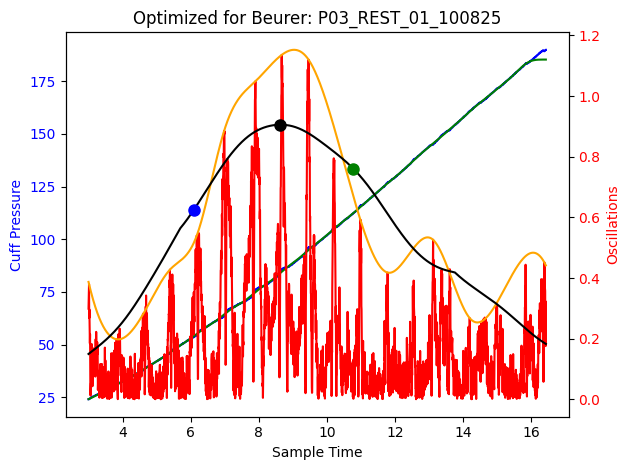

Analysieren der Messung: P03_REST_02_160925


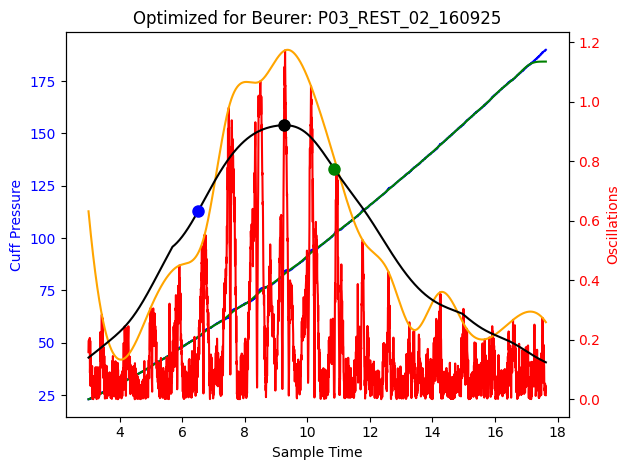

Analysieren der Messung: P03_ACTIV_02_160925


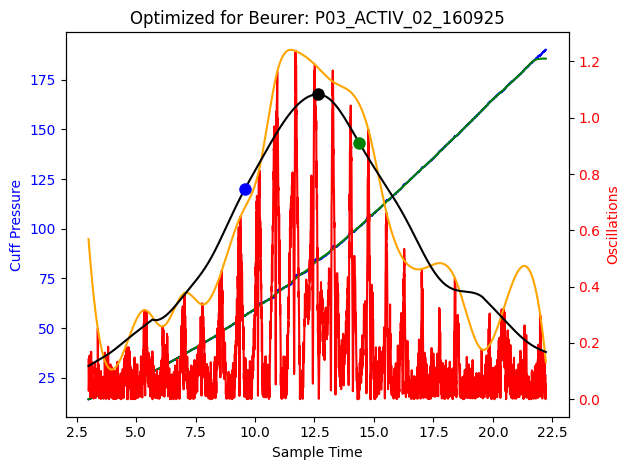

Analysieren der Messung: P04_REST_01_160925


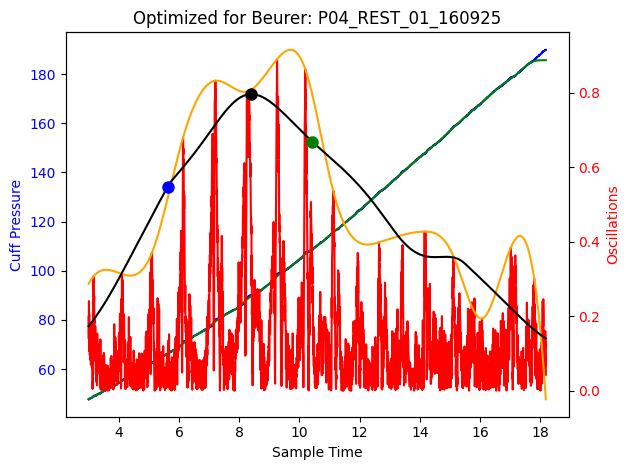

Analysieren der Messung: P04_ACTIV_01_160925


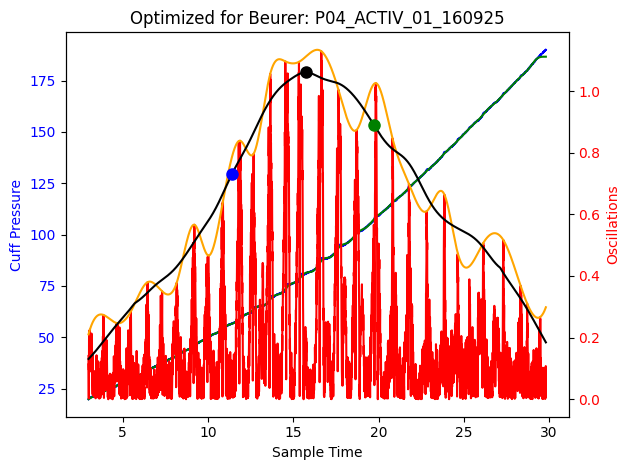

Analysieren der Messung: P05_REST_01_210925


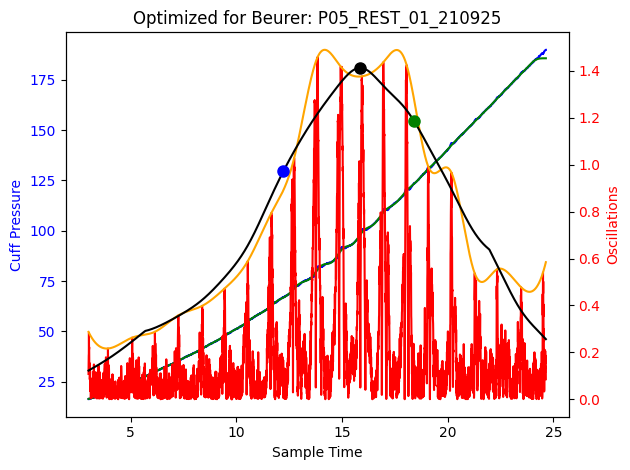

Analysieren der Messung: P05_ACTIV_01_210925


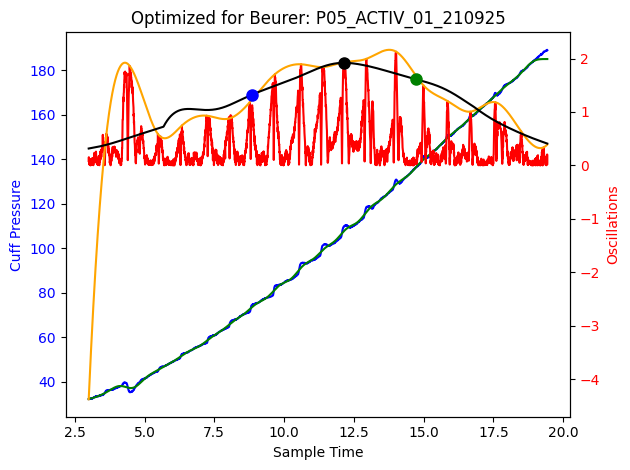

Analysieren der Messung: P06_REST_01_191025


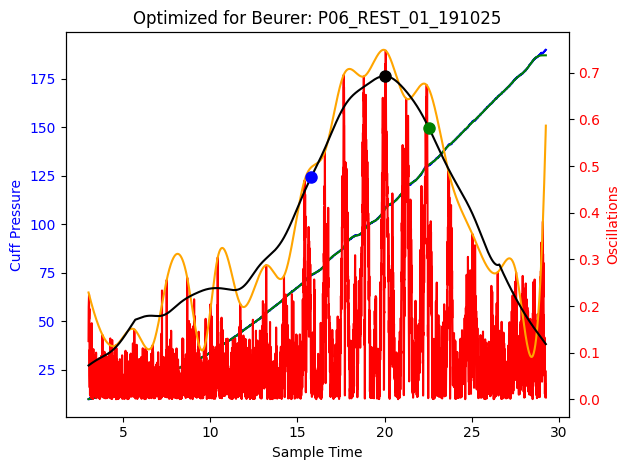

Analysieren der Messung: P06_ACTIV_01_191025


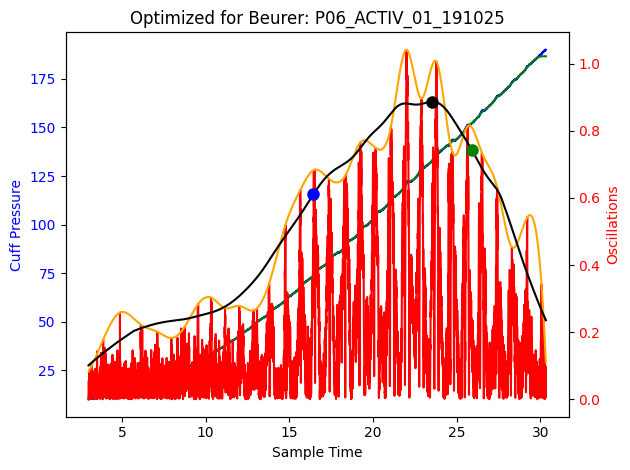

Analysieren der Messung: P07_REST_01_191025


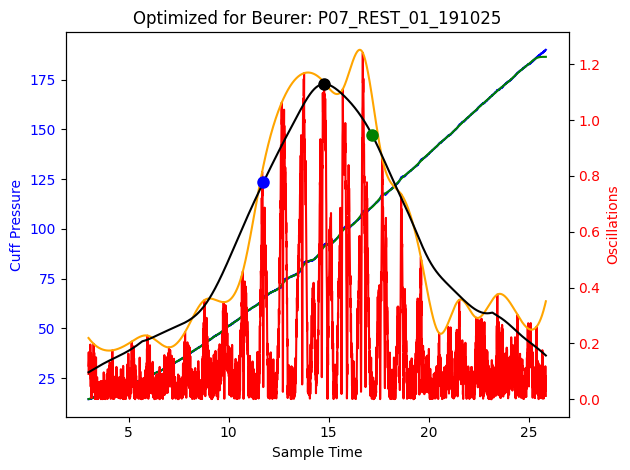

Analysieren der Messung: P07_ACTIV_01_191025


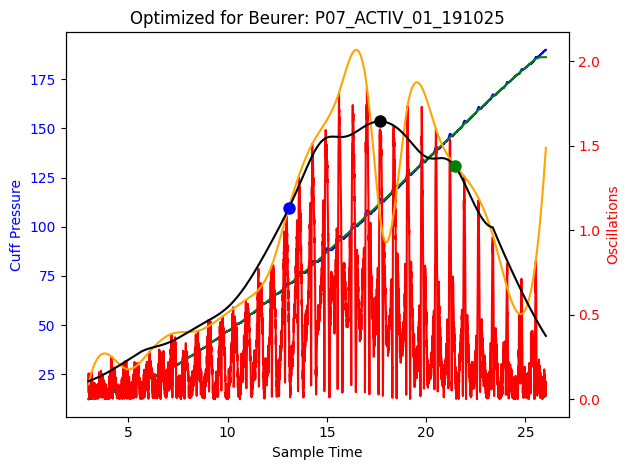

Analysieren der Messung: P08_REST_01_201025


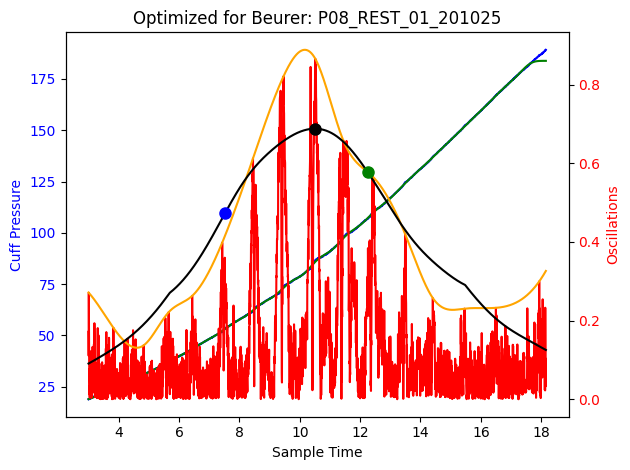

Analysieren der Messung: P08_ACTIV_01_201025


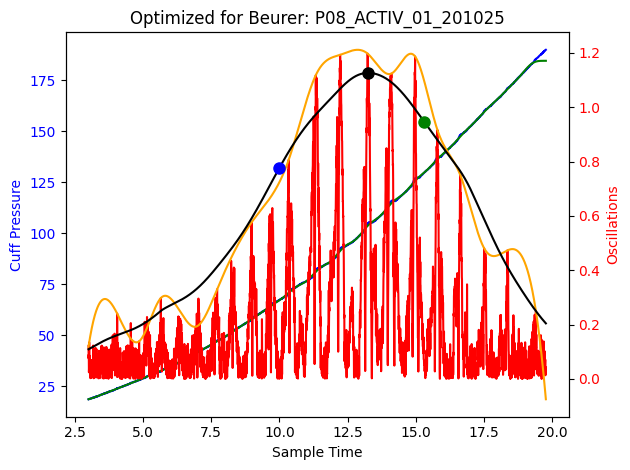

In [2]:
run_analysis(catagories[1])

### Messungen optimiert auf NAIS

In [ ]:
run_analysis(catagories[2])